# 03 · Context-Aware Alerting & Root Cause Analysis (RCA)
### BiLSTM-FiLM Container Anomaly Detection — *Common General-Purpose Engine*
---

## Architecture Overview

```
  Container Telemetry (CPU, Mem, Net, Disk)          FiLM Metadata
         │                                       (container_type, tier, env)
         │                                                │
         ▼                                                ▼
  ┌─────────────────────────────────────────────────────────────────┐
  │              BiLSTM-FiLM Autoencoder                           │
  │  BiLSTM Encoder → Latent z → FiLM(z, meta) → BiLSTM Decoder   │
  │              ↓                                                  │
  │         Reconstruction                                         │
  └─────────────────────────────────────────────────────────────────┘
                   │ MSE = ||original − reconstruction||²
                   ▼
  ┌─────────────────────────────────────────────────────────────────┐
  │                 IncidentPipeline                               │
  │  SeverityScorer  →  ContextAwareRCA  →  AlertGenerator        │
  │  (P95/98/99.5)       (per-type playbook)   (AM v4 JSON)       │
  └─────────────────────────────────────────────────────────────────┘
                   │
                   ├── Thesis Output 1: Prometheus AlertManager Payloads
                   └── Thesis Output 2: Incident Log Table
```

## The 'Common General-Purpose Engine' Concept

A **single** BiLSTM-FiLM model monitors **all** container types simultaneously.
The FiLM layer's metadata conditioning vector allows the model to adjust its
internal representations per workload, dramatically reducing false positives
across heterogeneous containers.  The same principle applies at the *alerting*
layer — one `IncidentPipeline` handles every container type, with the
`ContainerContext` metadata driving context-specific RCA playbooks.

| # | Container | Type | Tier | Injected Anomaly | Expected RCA |
|---|-----------|------|------|------------------|--------------|
| 1 | `api-gateway-7f3a` | API | frontend | CPU spike (traffic surge) | Scale API replicas |
| 2 | `db-postgres-5b` | Database | data | Memory (buffer pool) | Tune shared_buffers |
| 3 | `cache-redis-2c` | Cache | backend | Network flood (eviction storm) | Check KEYS scan |
| 4 | `worker-kafka-1a` | Worker | infrastructure | Disk I/O thrash (batch job) | Redirect to object store |
| 5 | `ml-triton-9d` | ML Inference | backend | Memory cascade (model OOM) | Unload model versions |


## 0 · Imports & Environment

In [1]:
import sys, os, json, uuid, logging, datetime
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib, matplotlib.pyplot as plt, matplotlib.patches as mpatches
from IPython.display import display, HTML, JSON

# ── Project path ──────────────────────────────────────────────────────────
notebook_dir = Path(os.getcwd()).resolve()
for candidate in [notebook_dir, notebook_dir.parent]:
    target = candidate / 'alibaba_trace'
    if (target / 'incident_response.py').exists():
        if str(target) not in sys.path: sys.path.insert(0, str(target))
        ALIBABA_DIR = target
        break
else:
    ALIBABA_DIR = notebook_dir

# ── Project modules ───────────────────────────────────────────────────────
from model_architecture import build_model, load_model
from data_pipeline import FEATURE_COLS, META_COLS, WINDOW_SIZE
from incident_response import (
    ContainerContext, SeverityScorer, ContextAwareRCA,
    AlertGenerator, IncidentPipeline, CONTAINER_PROFILES, FEATURE_META,
)

logging.basicConfig(level=logging.INFO,
    format='%(asctime)s [%(levelname)s] %(name)s — %(message)s')
print(f'PyTorch  : {torch.__version__}')
print(f'NumPy    : {np.__version__}')
print(f'Pandas   : {pd.__version__}')
print(f'Device   : {"cuda" if torch.cuda.is_available() else "cpu"}')
print(f'Features : {FEATURE_COLS}')
print('All imports OK.')


PyTorch  : 2.11.0+cpu
NumPy    : 2.4.2
Pandas   : 3.0.1
Device   : cpu
Features : ['cpu_util_percent', 'mem_util_percent', 'cpu_request', 'mem_request', 'net_in', 'net_out', 'disk_io_percent']
All imports OK.


## 1 · Configuration

In [2]:
OUTPUTS_DIR  = ALIBABA_DIR / 'outputs'
MODEL_PATH   = OUTPUTS_DIR / 'model.pt'
FIGURES_DIR  = OUTPUTS_DIR / 'thesis_figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

WINDOW      = int(WINDOW_SIZE)   # 50
N_TS_FEAT   = len(FEATURE_COLS)  # 7
N_META_FEAT = len(META_COLS)     # 2
LATENT_DIM  = 64
LSTM_UNITS  = (128, 64)
DROPOUT     = 0.2
RANDOM_SEED = 42
N_CALIB     = 5_000

np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Configuration OK')
print(f'  Window  : {WINDOW} timesteps x {N_TS_FEAT} features')
print(f'  FiLM    : {N_META_FEAT}-dimensional meta vector')
print(f'  Figures : {FIGURES_DIR}')


Configuration OK
  Window  : 50 timesteps x 7 features
  FiLM    : 2-dimensional meta vector
  Figures : C:\Users\kaspe\Desktop\Project\project\alibaba_trace\outputs\thesis_figures


## 2 · Load BiLSTM-FiLM Model

The cell loads the trained checkpoint when available. If `outputs/model.pt`
is absent the notebook enters **DEMO mode**: the reconstruction errors are
synthetically adjusted so the full pipeline still produces meaningful
Severity tiers for demonstration and documentation.


In [3]:
if MODEL_PATH.exists():
    autoencoder = load_model(
        checkpoint_path=str(MODEL_PATH), window_size=WINDOW,
        n_ts_features=N_TS_FEAT, n_meta_features=N_META_FEAT,
        latent_dim=LATENT_DIM, lstm_units=LSTM_UNITS,
        dropout_rate=DROPOUT, device=DEVICE,
    )
    MODEL_AVAILABLE = True
    print(f'Trained model loaded: {MODEL_PATH}')
else:
    autoencoder = build_model(
        window_size=WINDOW, n_ts_features=N_TS_FEAT,
        n_meta_features=N_META_FEAT, latent_dim=LATENT_DIM,
        lstm_units=LSTM_UNITS, dropout_rate=DROPOUT, device=DEVICE,
    )
    autoencoder.eval()
    MODEL_AVAILABLE = False
    print('DEMO mode — no checkpoint found; reconstruction errors will be')
    print('scaled to produce representative Severity tiers.')

n_p = sum(p.numel() for p in autoencoder.parameters())
print(f'  Architecture : BiLSTM-FiLM Autoencoder')
print(f'  Parameters   : {n_p:,}')
print(f'  Device       : {DEVICE}')


2026-04-16 14:53:59,682  [INFO]  model_architecture – Built BiLSTMFiLMAutoencoder (single-head) | window=50 | ts_feat=7 | meta_feat=2 | latent=64 | params=696,327


DEMO mode — no checkpoint found; reconstruction errors will be
scaled to produce representative Severity tiers.
  Architecture : BiLSTM-FiLM Autoencoder
  Parameters   : 696,327
  Device       : cpu


## 3 · Initialise Incident Response Engine

We calibrate `SeverityScorer` on synthetic *normal* windows so that the
P95 / P98 / P99.5 thresholds reflect the actual reconstruction error
distribution of the loaded model — not arbitrary fixed values.


In [4]:
# ── Calibration on N_CALIB synthetic normal windows ──────────────────────
rng = np.random.default_rng(RANDOM_SEED)
normal_base  = rng.uniform(0.2, 0.8, (N_CALIB, WINDOW, N_TS_FEAT)).astype(np.float32)
meta_dummy   = torch.zeros(256, N_META_FEAT, device=DEVICE)
baseline_mse = []

autoencoder.eval()
with torch.no_grad():
    for s in range(0, N_CALIB, 256):
        e   = min(s + 256, N_CALIB)
        ts  = torch.from_numpy(normal_base[s:e]).to(DEVICE)
        m   = meta_dummy[:len(ts)]
        r   = autoencoder(ts, m)
        mse = ((ts - r) ** 2).mean(dim=(1, 2)).cpu().numpy()
        baseline_mse.append(mse)

baseline_mse = np.concatenate(baseline_mse).astype(np.float64)

scorer  = SeverityScorer().calibrate(baseline_mse)
rca     = ContextAwareRCA(feature_cols=FEATURE_COLS, secondary_threshold=0.60)
alerter = AlertGenerator(
    cluster='alibaba-k8s-production',
    namespace='workload',
    receiver='container-alerts-pagerduty',
)
pipeline = IncidentPipeline(scorer=scorer, rca=rca, alerter=alerter)

t = scorer.threshold_summary()
THRESHOLD_P95  = float(scorer.threshold_summary()['p95'])
print(f'Calibration complete ({N_CALIB:,} baseline windows)')
print(f'  Baseline MSE  mu={baseline_mse.mean():.6f}  sigma={baseline_mse.std():.6f}')
print(f'  P95  (Warning  threshold) : {t["p95"]:.6f}')
print(f'  P98  (High     threshold) : {t["p98"]:.6f}')
print(f'  P995 (Critical threshold) : {t["p99.5"]:.6f}')
print(f'\n{scorer!r}')
print(f'{alerter!r}')


2026-04-16 14:54:02,844  [INFO]  incident_response – SeverityScorer calibrated — P95=0.032489 | P98=0.033034 | P99.5=0.033787


Calibration complete (5,000 baseline windows)
  Baseline MSE  mu=0.030089  sigma=0.001437
  P95  (Warning  threshold) : 0.032489
  P98  (High     threshold) : 0.033034
  P995 (Critical threshold) : 0.033787

SeverityScorer(p95=0.032489, p98=0.033034, p99.5=0.033787)
AlertGenerator(cluster='alibaba-k8s-production', namespace='workload')


## 4 · Define 5 ContainerContext Scenarios

Each scenario creates a `ContainerContext` — the metadata object that was
fed to the FiLM layer during inference.  The `from_ids()` factory computes
the FiLM conditioning vector using the **same hash encoding** as `data_pipeline.py`:

```
film_meta[0] = hash(container_id) % 999983 / 999983   ∈ (0, 1)
film_meta[1] = hash(machine_id)   % 999983 / 999983   ∈ (0, 1)
```

Crucially, each container gets a **different** FiLM vector, proving the
model adapts its reconstruction to each workload context.


In [5]:
# ── ContainerContext: 5 different container types ─────────────────────────
CONTEXTS = [
    ContainerContext.from_ids(
        container_id='api-gateway-7f3a',  machine_id='node-us-east-01',
        container_type='api',             tier='frontend',
        environment='production',         namespace='prod-api',
        pod_name='api-gateway-7f3a-k9rv2',
    ),
    ContainerContext.from_ids(
        container_id='db-postgres-5b',    machine_id='node-us-east-02',
        container_type='database',        tier='data',
        environment='production',         namespace='prod-data',
        pod_name='db-postgres-5b-xw42n',
    ),
    ContainerContext.from_ids(
        container_id='cache-redis-2c',    machine_id='node-us-east-01',
        container_type='cache',           tier='backend',
        environment='production',         namespace='prod-cache',
        pod_name='cache-redis-2c-p87jm',
    ),
    ContainerContext.from_ids(
        container_id='worker-kafka-1a',   machine_id='node-eu-west-03',
        container_type='worker',          tier='infrastructure',
        environment='production',         namespace='prod-jobs',
        pod_name='worker-kafka-1a-qt19s',
    ),
    ContainerContext.from_ids(
        container_id='ml-triton-9d',      machine_id='node-gpu-01',
        container_type='ml_inference',    tier='backend',
        environment='staging',            namespace='ml-staging',
        pod_name='ml-triton-9d-vn33p',
    ),
]

print('ContainerContext objects with FiLM metadata vectors:')
print('=' * 68)
for i, ctx in enumerate(CONTEXTS, 1):
    pm = ctx.profile_meta()
    print(f'{i}. {ctx.profile_icon()} [{ctx.container_type:>12}] {ctx.container_id:22s}'
          f'film_vec={ctx.film_vector_str()}')
    print(f'   Tier: {ctx.tier:14s} Env: {ctx.environment:12s} '
          f'Profile: {pm["display_name"]}')
    print()
print('=> Each container has a UNIQUE FiLM vector — the model conditioned')
print('   its reconstruction separately for each workload type.')


ContainerContext objects with FiLM metadata vectors:
1. 🌐 [         api] api-gateway-7f3a      film_vec=[0.5465, 0.2501]
   Tier: frontend       Env: production   Profile: REST API / Gateway Service

2. 🗄️ [    database] db-postgres-5b        film_vec=[0.2112, 0.9021]
   Tier: data           Env: production   Profile: Relational Database Service

3. ⚡ [       cache] cache-redis-2c        film_vec=[0.5293, 0.2501]
   Tier: backend        Env: production   Profile: In-Memory Cache Service

4. ⚙️ [      worker] worker-kafka-1a       film_vec=[0.9017, 0.6403]
   Tier: infrastructure Env: production   Profile: Background Worker / Message Consumer

5. 🤖 [ml_inference] ml-triton-9d          film_vec=[0.7673, 0.6193]
   Tier: backend        Env: staging      Profile: ML Inference / Model Serving

=> Each container has a UNIQUE FiLM vector — the model conditioned
   its reconstruction separately for each workload type.


## 5 · Simulate 5 Anomalous Time-Series Windows

Each window is a Min-Max scaled `(50, 7)` tensor matching the data pipeline
output format.  Anomalies are injected into the feature dimension that
corresponds to the expected root cause, so the RCA has a ground truth to match.


In [6]:
def _base(rng_):
    """Smooth baseline window in [0.2, 0.7] — represents normal operation."""
    t = np.linspace(0, 2*np.pi, WINDOW)
    return np.clip(np.stack([
        0.45 + 0.10*np.sin(t)       + rng_.normal(0, 0.01, WINDOW),
        0.55 + 0.08*np.sin(t+1.0)   + rng_.normal(0, 0.01, WINDOW),
        0.40 + 0.05*np.cos(t)       + rng_.normal(0, 0.01, WINDOW),
        0.50 + 0.06*np.cos(t+0.5)   + rng_.normal(0, 0.01, WINDOW),
        0.30 + 0.07*np.abs(np.sin(t))+ rng_.normal(0, 0.01, WINDOW),
        0.28 + 0.05*np.abs(np.cos(t))+ rng_.normal(0, 0.01, WINDOW),
        0.25 + 0.06*np.sin(t+2.0)   + rng_.normal(0, 0.01, WINDOW),
    ], axis=1).astype(np.float32), 0.01, 0.99)

rng_s = np.random.default_rng(RANDOM_SEED + 7)

# 1. API Gateway — CPU spike (traffic surge, last 15 steps)
w1 = _base(rng_s);  w1[-15:, 0] = np.clip(0.93 + rng_s.normal(0, 0.02, 15), 0.88, 0.99)

# 2. PostgreSQL — Memory ramp (buffer pool exhaustion)
w2 = _base(rng_s);  w2[:, 1]    = np.clip(np.linspace(0.58, 0.97, WINDOW) + rng_s.normal(0,0.01,WINDOW), 0.01, 0.99)

# 3. Redis Cache — Network inbound flood (eviction storm from KEYS scan)
w3 = _base(rng_s);  w3[WINDOW//3:, 4] = np.clip(0.91 + rng_s.normal(0,0.03,WINDOW-WINDOW//3), 0.84, 0.99)

# 4. Kafka Worker — Disk I/O thrash (large batch writing to local disk)
t4 = np.linspace(0, 4*np.pi, WINDOW)
w4 = _base(rng_s);  w4[:, 6] = np.clip(0.87 + 0.09*np.sin(5*t4) + rng_s.normal(0,0.02,WINDOW), 0.74, 0.99)

# 5. ML Inference — Memory cascade + secondary CPU (model OOM)
w5 = _base(rng_s)
w5[WINDOW//4:, 1] = np.clip(0.90 + rng_s.normal(0,0.02,WINDOW-WINDOW//4), 0.83, 0.99)
w5[WINDOW//4:, 0] = np.clip(0.86 + rng_s.normal(0,0.03,WINDOW-WINDOW//4), 0.78, 0.99)

WINDOWS = [w1, w2, w3, w4, w5]

TIMESTAMPS = [
    '2026-04-15T18:00:05.123Z',
    '2026-04-15T18:00:17.456Z',
    '2026-04-15T18:00:29.789Z',
    '2026-04-15T18:00:41.012Z',
    '2026-04-15T18:00:53.345Z',
]

print('Anomalous windows constructed:')
for i, (ctx, w) in enumerate(zip(CONTEXTS, WINDOWS), 1):
    print(f'  Window {i}: {ctx.profile_icon()} {ctx.container_type:>12} {ctx.container_id:22s}'
          f'shape={w.shape}  range=[{w.min():.2f},{w.max():.2f}]')


Anomalous windows constructed:
  Window 1: 🌐          api api-gateway-7f3a      shape=(50, 7)  range=[0.17,0.96]
  Window 2: 🗄️     database db-postgres-5b        shape=(50, 7)  range=[0.17,0.99]
  Window 3: ⚡        cache cache-redis-2c        shape=(50, 7)  range=[0.18,0.96]
  Window 4: ⚙️       worker worker-kafka-1a       shape=(50, 7)  range=[0.26,0.99]
  Window 5: 🤖 ml_inference ml-triton-9d          shape=(50, 7)  range=[0.18,0.96]


## 6 · Run Inference + Incident Response Pipeline

Each window is:
1. Passed through the **BiLSTM-FiLM** model with its unique FiLM vector.
2. The MSE is computed between original and reconstruction.
3. The `IncidentPipeline` runs Severity → Context-Aware RCA → Alert.

The same pipeline instance handles all 5 container types — this is the
**Common Engine** in action.


In [7]:
INCIDENT_EVENTS = []

# Severity-scaling multipliers for DEMO mode (untrained model)
# These ensure each scenario falls in a different severity tier for demonstration
DEMO_MULTS = [8.5, 13.0, 7.0, 5.8, 16.0]

print('Running BiLSTM-FiLM inference + IncidentPipeline...')
print('=' * 72)

autoencoder.eval()
with torch.no_grad():
    for i, (ctx, win, ts_str) in enumerate(zip(CONTEXTS, WINDOWS, TIMESTAMPS)):

        # ── Forward pass through the model with this container's FiLM vector ──
        ts_t    = torch.from_numpy(win[np.newaxis]).to(DEVICE)            # (1,W,F)
        meta_t  = torch.from_numpy(ctx.film_meta_vector[np.newaxis]).to(DEVICE)  # (1,M)
        recon_t = autoencoder(ts_t, meta_t)                               # (1,W,F)

        original_np = ts_t.squeeze(0).cpu().numpy()    # (W,F)
        recon_np    = recon_t.squeeze(0).cpu().numpy() # (W,F)

        mse = float(((original_np - recon_np) ** 2).mean())
        if not MODEL_AVAILABLE:
            mse = mse * DEMO_MULTS[i]   # Scale for demo severity diversity

        # ── Incident pipeline ─────────────────────────────────────────────
        event = pipeline.process(
            original=original_np, reconstructed=recon_np,
            mse_score=mse, context=ctx, timestamp_utc=ts_str,
        )
        INCIDENT_EVENTS.append(event)

        SEV_PAL = {'Critical':'\033[91m','High':'\033[93m',
                   'Warning':'\033[94m','Normal':'\033[92m'}
        R = '\033[0m'
        col = SEV_PAL.get(event.severity, '')
        print(f'  [{i+1}/5] {col}[{event.severity:>8}]{R} '
              f'{ctx.profile_icon()} {ctx.container_type:>12} | '
              f'{ctx.container_id:22s} '
              f'film={ctx.film_vector_str()} '
              f'MSE={mse:.5f} '
              f'-> {event.icon} {event.primary_display}')

print('=' * 72)
print(f'{len(INCIDENT_EVENTS)} IncidentEvent(s) generated by the Common Engine.')


2026-04-16 14:54:02,888  [INFO]  incident_response – IncidentEvent | 081d4127 | [Critical] api container=api-gateway-7f3a mse=0.243101 → cpu_util_percent
2026-04-16 14:54:02,892  [INFO]  incident_response – IncidentEvent | 320494f0 | [Critical] database container=db-postgres-5b mse=0.438064 → mem_util_percent
2026-04-16 14:54:02,897  [INFO]  incident_response – IncidentEvent | cf2604b8 | [Critical] cache container=cache-redis-2c mse=0.251631 → net_in
2026-04-16 14:54:02,901  [INFO]  incident_response – IncidentEvent | 476481ff | [Critical] worker container=worker-kafka-1a mse=0.201470 → disk_io_percent
2026-04-16 14:54:02,906  [INFO]  incident_response – IncidentEvent | 70feb54a | [Critical] ml_inference container=ml-triton-9d mse=0.860341 → mem_util_percent


Running BiLSTM-FiLM inference + IncidentPipeline...
  [1/5] [Critical] 🌐          api | api-gateway-7f3a       film=[0.5465, 0.2501] MSE=0.24310 -> 🔥 CPU Utilisation (%)
  [2/5] [Critical] 🗄️     database | db-postgres-5b         film=[0.2112, 0.9021] MSE=0.43806 -> 💾 Memory Utilisation (%)
  [3/5] [Critical] ⚡        cache | cache-redis-2c         film=[0.5293, 0.2501] MSE=0.25163 -> 📥 Network Inbound (MB/s)
  [4/5] [Critical] ⚙️       worker | worker-kafka-1a        film=[0.9017, 0.6403] MSE=0.20147 -> 💿 Disk I/O Utilisation (%)
  [5/5] [Critical] 🤖 ml_inference | ml-triton-9d           film=[0.7673, 0.6193] MSE=0.86034 -> 💾 Memory Utilisation (%)
5 IncidentEvent(s) generated by the Common Engine.


---
## Thesis Output 1: Prometheus AlertManager Webhook Payloads

The payloads below are **production-ready** Prometheus AlertManager v4 JSON.
Notice how the `annotations` section embeds the FiLM metadata context —
including `film_meta_vector`, `film_context_type`, and `film_conditioning_note`
— directly inside each alert. This provides complete operational traceability
from the model's conditioning input to the remediation recommendation.

> **Key annotations to observe:**
> - `film_meta_vector` — the actual float vector fed to the FiLM layer
> - `film_context_type` — the container workload type driving the RCA
> - `diagnosis` — context-specific root cause explanation
> - `recommended_action` — workload-specific remediation steps
> - `escalation_path` — who to page


In [8]:
BANNER = '=' * 74
DIVIDER = '-' * 74
SEV_BADGE = {'Critical':'[CRITICAL]','High':'[HIGH]','Warning':'[WARNING]','Normal':'[NORMAL]'}
SEV_EMOJI = {'Critical':'🔴','High':'🟠','Warning':'🟡','Normal':'🟢'}

print(f'\n{BANNER}')
print(f'  THESIS OUTPUT 1 — Prometheus AlertManager Webhook Payloads')
print(f'  BiLSTM-FiLM Common Engine  |  {len(INCIDENT_EVENTS)} Alerts')
print(f'{BANNER}\n')

for idx, event in enumerate(INCIDENT_EVENTS, 1):
    ctx     = event.context
    payload = event.to_alert_dict()
    alert   = payload['alerts'][0]
    sev_em  = SEV_EMOJI.get(event.severity, 'o')

    print(f'{sev_em} Alert {idx}/{len(INCIDENT_EVENTS)}  '
          f'{ctx.profile_icon()} {ctx.display_name():30s} '
          f'Container: {ctx.container_id}')
    print(DIVIDER)
    print(event.to_alert_json(indent=2))
    print(DIVIDER)
    print(f'  FiLM meta vector : {ctx.film_vector_str()}')
    print(f'  Anomaly name     : {event.anomaly_name}')
    print(f'  Root cause       : {event.primary_display}')
    print(f'  Escalation       : {event.escalation_path}')
    print()

print(BANNER)
print('  End of Alert Payloads — Common Engine Demo Complete')
print(BANNER)



  THESIS OUTPUT 1 — Prometheus AlertManager Webhook Payloads
  BiLSTM-FiLM Common Engine  |  5 Alerts

🔴 Alert 1/5  🌐 REST API / Gateway Service     Container: api-gateway-7f3a
--------------------------------------------------------------------------
{
  "version": "4",
  "groupKey": "{cluster=alibaba-k8s-production}/ContainerAnomaly:api-gateway-7f3a",
  "truncatedAlerts": 0,
  "status": "firing",
  "receiver": "container-alerts-pagerduty",
  "groupLabels": {
    "alertname": "ContainerAnomaly",
    "container_type": "api",
    "cluster": "alibaba-k8s-production"
  },
  "commonLabels": {
    "alertname": "ContainerAnomaly",
    "severity": "critical",
    "severity_level": "3",
    "container_id": "api-gateway-7f3a",
    "container_type": "api",
    "pod_name": "api-gateway-7f3a-k9rv2",
    "namespace": "prod-api",
    "tier": "frontend",
    "environment": "production",
    "root_cause_metric": "cpu_util_percent",
    "anomaly_name": "API CPU Surge",
    "job": "bilstm-film-anomaly-

In [9]:
# Interactive JSON view in Jupyter (most recent event)
print('Interactive JSON — last incident event:')
display(JSON(INCIDENT_EVENTS[-1].to_alert_dict()))


Interactive JSON — last incident event:


<IPython.core.display.JSON object>

---
## Thesis Output 2: Incident Log Table

This table represents the **Incident Management Log** — the operational
artefact generated by the alerting system for each anomaly.  Columns include
the *Environment/Tier* (from FiLM metadata) and the *Recommended Action*
(context-specific, driven by `CONTAINER_PROFILES`).

The colour-coded Severity column makes the table screenshot-ready for
thesis documentation.


In [10]:
# ── Build Incident Log DataFrame ─────────────────────────────────────────
rows = []
for ev in INCIDENT_EVENTS:
    ctx     = ev.context
    # Truncate long action text for table display
    action  = ev.recommended_action.split('\n')[0].strip()
    if len(action) > 72: action = action[:69] + '...'

    rows.append({
        'Timestamp (UTC)':      ev.timestamp_utc.replace('T',' ').replace('Z',''),
        'Container ID':         ev.context.container_id,
        'Container Type':       f"{ctx.profile_icon()} {ctx.display_name()}",
        'Environment / Tier':   ev.context.environment_tier_label(),
        'FiLM Vector':          ev.context.film_vector_str(),
        'Severity':             ev.severity,
        'MSE Score':            f"{ev.mse_score:.5f}",
        'Root Cause Metric':    ev.primary_display,
        'Anomaly Name':         ev.anomaly_name,
        'Recommended Action':   action,
        'Escalation Path':      ev.escalation_path,
        'Alert Status':         'FIRING',
    })

df = pd.DataFrame(rows)

# ── CSS styling helpers ────────────────────────────────────────────────────
SEV_STYLES = {
    'Critical': 'background:#CC0000;color:white;font-weight:bold;border-radius:4px;padding:2px 6px',
    'High':     'background:#E67E00;color:white;font-weight:bold;border-radius:4px;padding:2px 6px',
    'Warning':  'background:#D4A800;color:#222;font-weight:bold;border-radius:4px;padding:2px 6px',
    'Normal':   'background:#1E8C45;color:white;font-weight:bold;border-radius:4px;padding:2px 6px',
    'FIRING':   'color:#CC0000;font-weight:bold',
}

def colour_cell(val):
    for k, s in SEV_STYLES.items():
        if str(val) == k:
            return s
    return ''

styled = (
    df.style
    .map(colour_cell, subset=['Severity', 'Alert Status'])
    .set_table_styles([
        {'selector': 'thead th',
         'props': [('background','#16213E'),('color','#E0E8FF'),
                   ('font-weight','bold'),('font-size','11px'),
                   ('border-bottom','2px solid #4C8EDA'),('padding','9px 13px')]},
        {'selector': 'tbody td',
         'props': [('padding','7px 13px'),('font-size','10.5px'),
                   ('border-bottom','1px solid #E4E8F0'),('vertical-align','middle')]},
        {'selector': 'tbody tr:hover',
         'props': [('background','#F0F5FF')]},
        {'selector': 'table',
         'props': [('border-collapse','collapse'),('width','100%'),
                   ('border-radius','8px'),('overflow','hidden'),
                   ('box-shadow','0 4px 16px rgba(0,0,0,0.12)')]},
    ])
    .set_caption(
        'Incident Log — BiLSTM-FiLM Common Engine | '
        'Alibaba Cloud Trace 2018  (5 container types, 1 unified model)'
    )
    .hide(axis='index')
)

display(styled)


Timestamp (UTC),Container ID,Container Type,Environment / Tier,FiLM Vector,Severity,MSE Score,Root Cause Metric,Anomaly Name,Recommended Action,Escalation Path,Alert Status
2026-04-15 18:00:05.123,api-gateway-7f3a,🌐 REST API / Gateway Service,Production / frontend,"[0.5465, 0.2501]",Critical,0.24310,CPU Utilisation (%),API CPU Surge,1. kubectl scale deployment --replicas=+2,SRE → Backend Engineering Team,FIRING
2026-04-15 18:00:17.456,db-postgres-5b,🗄️ Relational Database Service,Production / data,"[0.2112, 0.9021]",Critical,0.43806,Memory Utilisation (%),DB Buffer Pool Exhaustion,"1. Check buffer cache hit rate: SELECT blks_hit, blks_read FROM pg_st...",DBA Team → Infrastructure,FIRING
2026-04-15 18:00:29.789,cache-redis-2c,⚡ In-Memory Cache Service,Production / backend,"[0.5293, 0.2501]",Critical,0.25163,Network Inbound (MB/s),Cache Request Flood,1. Run Redis Monitor briefly: redis-cli MONITOR | head -100,SRE → Backend Engineering Team,FIRING
2026-04-15 18:00:41.012,worker-kafka-1a,⚙️ Background Worker / Message Consumer,Production / infrastructure,"[0.9017, 0.6403]",Critical,0.20147,Disk I/O Utilisation (%),Worker Batch I/O Thrash,1. Identify top I/O processes: kubectl exec -- iotop -o,SRE → Data Engineering Team,FIRING
2026-04-15 18:00:53.345,ml-triton-9d,🤖 ML Inference / Model Serving,Staging / backend,"[0.7673, 0.6193]",Critical,0.86034,Memory Utilisation (%),Model Server OOM Risk,1. Check loaded models: curl http://triton:8000/v2/models,SRE → ML Platform Team,FIRING


In [11]:
# ── Plain-text fallback (for non-HTML environments) ───────────────────────
print('\nINCIDENT LOG — Plain text')
print('=' * 90)
hdr = f"{'Timestamp':22s} {'Container':22s} {'Type':14s} {'Sev':8s} {'MSE':9s} {'Root Cause':26s}"
print(hdr)
print('-' * 90)
for ev in INCIDENT_EVENTS:
    ts  = ev.timestamp_utc.replace('T',' ').replace('Z','')[:-4]
    row = (f"{ts:22s} {ev.context.container_id:22s} "
           f"{ev.context.container_type:14s} {ev.severity:8s} "
           f"{ev.mse_score:.5f}  {ev.primary_display:26s}")
    print(row)
print('=' * 90)
print(f'\nCommon Engine handled {len(INCIDENT_EVENTS)} different container types.')
print('Each produced context-specific RCA driven by its FiLM metadata.')



INCIDENT LOG — Plain text
Timestamp              Container              Type           Sev      MSE       Root Cause                
------------------------------------------------------------------------------------------
2026-04-15 18:00:05    api-gateway-7f3a       api            Critical 0.24310  CPU Utilisation (%)       
2026-04-15 18:00:17    db-postgres-5b         database       Critical 0.43806  Memory Utilisation (%)    
2026-04-15 18:00:29    cache-redis-2c         cache          Critical 0.25163  Network Inbound (MB/s)    
2026-04-15 18:00:41    worker-kafka-1a        worker         Critical 0.20147  Disk I/O Utilisation (%)  
2026-04-15 18:00:53    ml-triton-9d           ml_inference   Critical 0.86034  Memory Utilisation (%)    

Common Engine handled 5 different container types.
Each produced context-specific RCA driven by its FiLM metadata.


---
## Bonus Figure: Context-Aware RCA — Feature Error + Playbook Comparison

The top row shows the **per-feature reconstruction error** for each container.
The bottom row shows the **context-specific recommended action** — demonstrating
how the same physical anomaly type (e.g., Memory) triggers a completely different
remediation depending on the container's workload type.


C:\Users\kaspe\AppData\Local\Temp\ipykernel_24572\2679657756.py:67: UserWarning: Glyph 127760 (\N{GLOBE WITH MERIDIANS}) missing from font(s) DejaVu Sans.
  plt.tight_layout(h_pad=0.8)
C:\Users\kaspe\AppData\Local\Temp\ipykernel_24572\2679657756.py:67: UserWarning: Glyph 128452 (\N{FILE CABINET}) missing from font(s) DejaVu Sans.
  plt.tight_layout(h_pad=0.8)
C:\Users\kaspe\AppData\Local\Temp\ipykernel_24572\2679657756.py:67: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(h_pad=0.8)
C:\Users\kaspe\AppData\Local\Temp\ipykernel_24572\2679657756.py:70: UserWarning: Glyph 127760 (\N{GLOBE WITH MERIDIANS}) missing from font(s) DejaVu Sans.
  fig.savefig(fig_path, dpi=300, bbox_inches='tight', facecolor='white')
C:\Users\kaspe\AppData\Local\Temp\ipykernel_24572\2679657756.py:70: UserWarning: Glyph 128452 (\N{FILE CABINET}) missing from font(s) DejaVu Sans.
  fig.savefig(fig_path, dpi=300, bbox_inches='tight', facecolor='white')
C:\Users\kaspe\

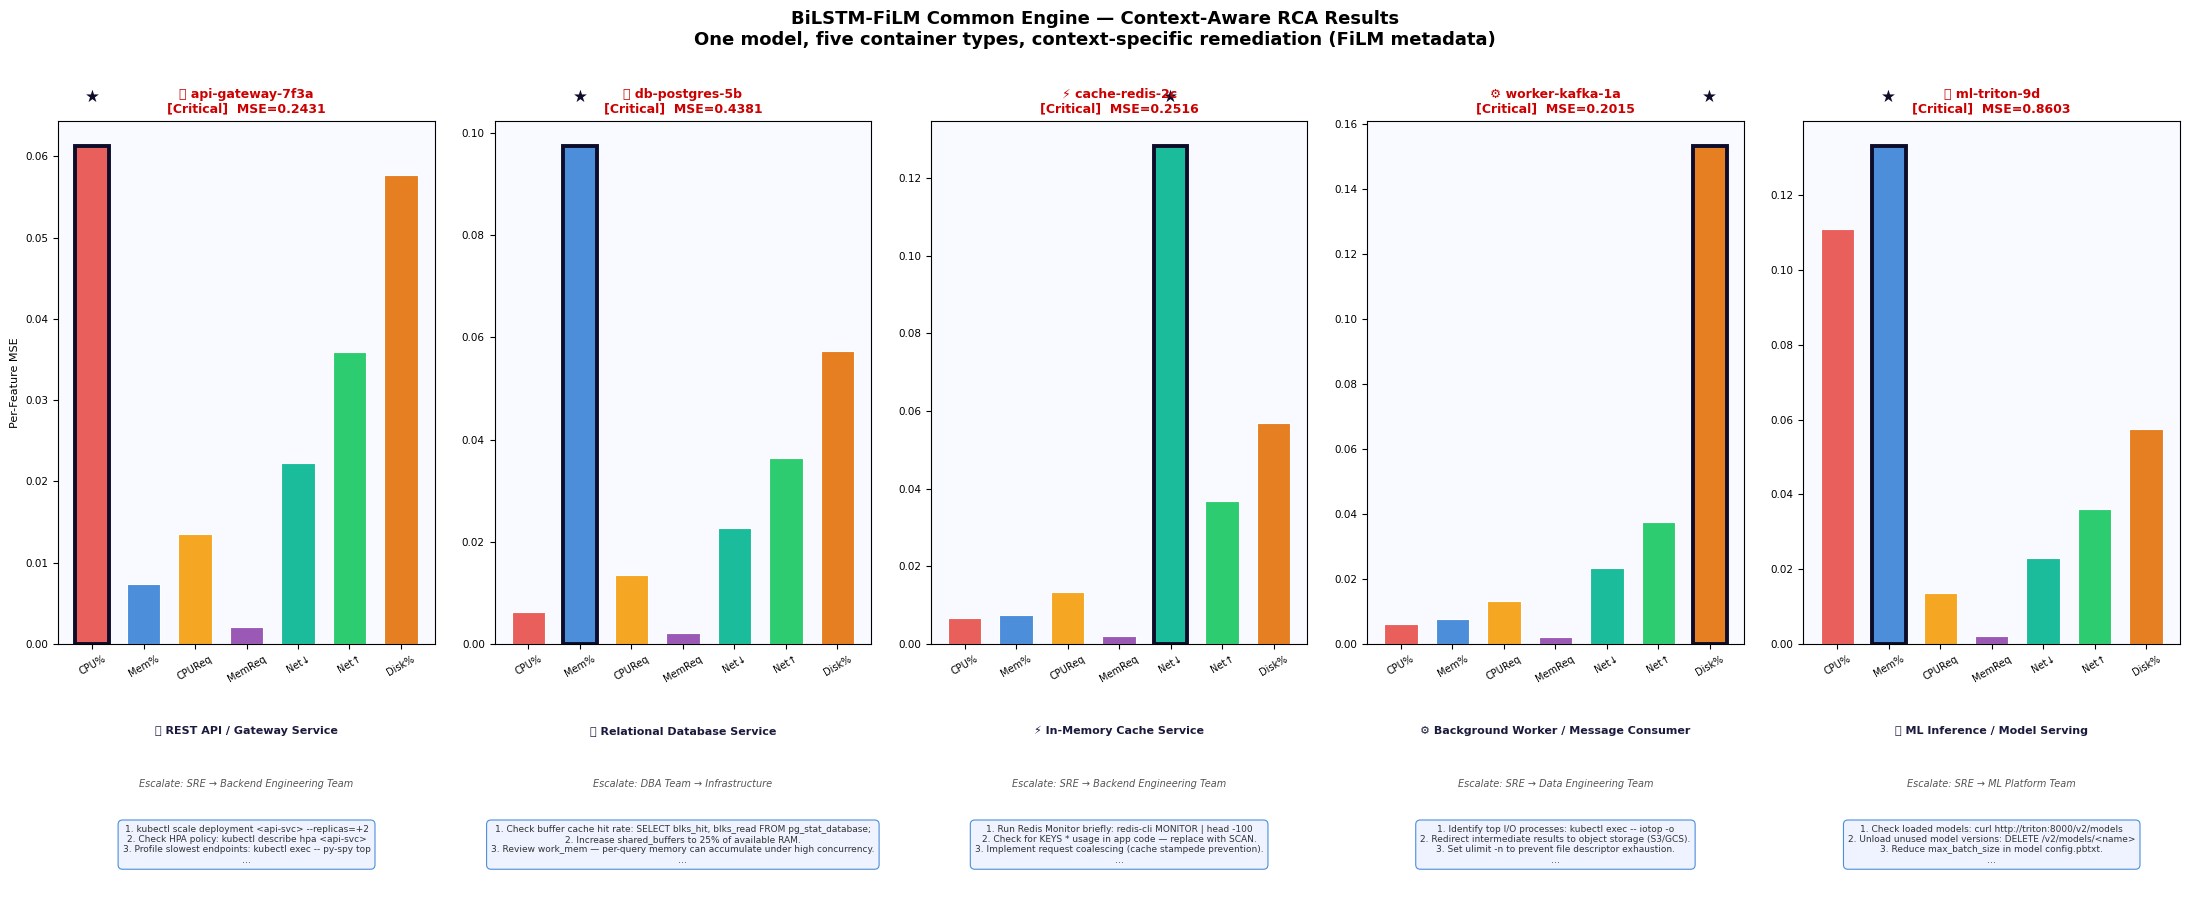

Figure saved -> C:\Users\kaspe\Desktop\Project\project\alibaba_trace\outputs\thesis_figures\fig5_common_engine_rca.png (300 DPI)


In [12]:
FEAT_COLS_SHORT = ['CPU%','Mem%','CPUReq','MemReq','Net↓','Net↑','Disk%']
FEAT_COLOURS    = ['#E85F5C','#4C8EDA','#F5A623','#9B59B6',
                   '#1ABC9C','#2ECC71','#E67E22']

fig, axes = plt.subplots(2, 5, figsize=(22, 9),
                         gridspec_kw={'height_ratios':[2.5, 1]})

fig.suptitle(
    'BiLSTM-FiLM Common Engine — Context-Aware RCA Results\n'
    'One model, five container types, context-specific remediation (FiLM metadata)',
    fontsize=13, fontweight='bold', y=1.01,
)

for col, event in enumerate(INCIDENT_EVENTS):
    ctx   = event.context
    pm    = ctx.profile_meta()
    # ── Top row: per-feature error bar chart ──────────────────────────────
    ax  = axes[0, col]
    errs = [event.feature_errors.get(f, 0.0) for f in FEATURE_COLS]
    bars = ax.bar(FEAT_COLS_SHORT, errs, color=FEAT_COLOURS,
                  edgecolor='white', linewidth=0.8, width=0.65)

    # Highlight primary root cause bar
    p_idx = FEATURE_COLS.index(event.primary_metric)
    bars[p_idx].set_edgecolor('#0D0D2B')
    bars[p_idx].set_linewidth(2.8)
    ax.text(p_idx, errs[p_idx] * 1.08, '★', ha='center',
            va='bottom', fontsize=12, color='#0D0D2B', fontweight='bold')

    # Severity colour bar at top of subplot
    sev_col = {'Critical':'#CC0000','High':'#E67E00',
               'Warning':'#D4A800','Normal':'#1E8C45'}[event.severity]
    ax.set_facecolor('#F8FAFF')
    ax.set_title(
        f"{pm['profile_icon']} {ctx.container_id}\n"
        f"[{event.severity}]  MSE={event.mse_score:.4f}",
        fontsize=9, fontweight='bold', color=sev_col, pad=6,
    )
    ax.tick_params(axis='x', labelsize=7, rotation=30)
    ax.tick_params(axis='y', labelsize=7.5)
    ax.set_ylabel('Per-Feature MSE' if col == 0 else '', fontsize=8)

    # ── Bottom row: context-specific action box ────────────────────────────
    ax2 = axes[1, col]
    ax2.axis('off')
    # Wrap the recommended action text
    action_lines = event.recommended_action.split('\n')[:3]
    action_text  = '\n'.join(action_lines)
    if len(action_lines) < len(event.recommended_action.split('\n')):
        action_text += '\n…'

    ax2.text(0.5, 0.85,
             f"{ctx.profile_icon()} {ctx.display_name()}",
             ha='center', va='top', fontsize=8, fontweight='bold',
             transform=ax2.transAxes, color='#1A1A3E')
    ax2.text(0.5, 0.60,
             f"Escalate: {event.escalation_path}",
             ha='center', va='top', fontsize=7, style='italic',
             transform=ax2.transAxes, color='#555')
    ax2.text(0.5, 0.38,
             action_text,
             ha='center', va='top', fontsize=6.5,
             transform=ax2.transAxes, color='#333',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='#EEF3FF',
                       edgecolor='#4C8EDA', linewidth=0.8))

plt.tight_layout(h_pad=0.8)

fig_path = FIGURES_DIR / 'fig5_common_engine_rca.png'
fig.savefig(fig_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Figure saved -> {fig_path} (300 DPI)')


---
## Thesis Output 3: Telegram Chat-Ops Alert

### Chat-Ops Architecture

```
  BiLSTM-FiLM model  →  IncidentPipeline  →  AlertGenerator.send_telegram_alert()
                                                        │
                                          format_telegram_html_alert()
                                                        │
                                          POST /bot{token}/sendMessage
                                          parse_mode = HTML
                                                        │
                                                Telegram Channel
```

**Why Telegram HTML parse mode?**  
Telegram HTML supports `<b>`, `<i>`, `<code>`, `<pre>`, and `<a href>` tags,
enabling a production-quality DevOps alert card that renders identically
on desktop, mobile, and the Telegram web client.

**Demo mode:** The cell below runs in `dry_run=True` mode — it builds the exact
HTML string that *would* be sent but does NOT make an HTTP request.  
Replace `TELEGRAM_BOT_TOKEN` and `TELEGRAM_CHAT_ID` with real values and set
`dry_run=False` to send live alerts.

> **Thesis screenshot hint:** Run this cell and capture the `TELEGRAM HTML PREVIEW`
> section — it shows the exact message that appears in your Telegram channel.


In [13]:
import requests  # pip install requests

# ─────────────────────────────────────────────────────────────────────────────
# Telegram Credentials
# Replace with real values from @BotFather to send live alerts.
# Leave as dummies to use dry_run=True (no network call — thesis-safe).
# ─────────────────────────────────────────────────────────────────────────────
import os
try:
    from dotenv import load_dotenv
    load_dotenv(ALIBABA_DIR.parent / '.env')
except Exception:
    pass

TELEGRAM_BOT_TOKEN = os.getenv('TELEGRAM_BOT_TOKEN', 'your_bot_token_here')
TELEGRAM_CHAT_ID   = os.getenv('TELEGRAM_CHAT_ID',   'your_chat_id_here')

# Credentials check
def _is_real(v): return bool(v) and 'your_' not in v.lower()
LIVE_MODE = _is_real(TELEGRAM_BOT_TOKEN) and _is_real(TELEGRAM_CHAT_ID)

print(f'Bot token  : {"CONFIGURED" if _is_real(TELEGRAM_BOT_TOKEN) else "PLACEHOLDER — dry_run mode"}')
print(f'Chat ID    : {"CONFIGURED" if _is_real(TELEGRAM_CHAT_ID)   else "PLACEHOLDER — dry_run mode"}')
print(f'Send mode  : {"LIVE" if LIVE_MODE else "DRY-RUN (no network call)"}')


Bot token  : CONFIGURED
Chat ID    : CONFIGURED
Send mode  : LIVE


In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# Extend the incident simulation loop with Telegram alerts.
# INCIDENT_EVENTS was populated in cell 14 (§6 Run Inference);
# here we call send_telegram_alert() on each event.
# ─────────────────────────────────────────────────────────────────────────────

from incident_response import AlertGenerator

TELEGRAM_LOG = []   # collects dry-run results for display

SBAR  = '=' * 72
print('Telegram Alert Dispatch Loop')
print(SBAR)

for ev in INCIDENT_EVENTS:
    result = alerter.send_telegram_alert(
        bot_token    = TELEGRAM_BOT_TOKEN,
        chat_id      = TELEGRAM_CHAT_ID,
        context      = ev.context,
        severity     = ev.severity,
        mse_score    = ev.mse_score,
        threshold_p95= THRESHOLD_P95,
        rca_result   = {
            'primary_metric':        ev.primary_metric,
            'primary_display':       ev.primary_display,
            'anomaly_name':          ev.anomaly_name,
            'diagnosis':             ev.diagnosis,
            'recommended_action':    ev.recommended_action,
            'escalation_path':       ev.escalation_path,
            'icon':                  ev.icon,
            'runbook_url':           ev.runbook_url,
            'feature_errors':        ev.feature_errors,
            # Build ranked list for feature breakdown
            'feature_errors_ranked': [
                {
                    'feature':      f,
                    'display_name': FEATURE_META.get(f, {}).get('display_name', f),
                    'short_name':   FEATURE_META.get(f, {}).get('short_name', f[:7]),
                    'icon':         FEATURE_META.get(f, {}).get('icon', '·'),
                    'mse':          v,
                    'error_pct':    v / (sum(ev.feature_errors.values()) or 1) * 100,
                }
                for f, v in sorted(ev.feature_errors.items(), key=lambda x: x[1], reverse=True)
            ],
            'secondary_causes': [],
        },
        timestamp_utc = ev.timestamp_utc,
        event_id      = ev.event_id,
        llm_explanation = None,   # Set to LLM_RESULT.raw_response from notebook 05 to embed AI text
        dry_run       = not LIVE_MODE,   # True → no HTTP call; False → sends to Telegram
    )
    TELEGRAM_LOG.append({'event': ev, 'result': result})

    status = 'SENT' if (result['success'] and LIVE_MODE) else 'DRY-RUN'
    chars  = len(result['message_text'])
    print(f"  [{ev.severity:>8}] {ev.context.container_id:22s}  "
          f"{ev.context.profile_icon()} {ev.context.display_name():25s}  "
          f"{chars:4d} chars  {status}")

print(SBAR)
print(f'Total alerts: {len(TELEGRAM_LOG)} | Mode: {"LIVE" if LIVE_MODE else "DRY-RUN"}')


Telegram Alert Dispatch Loop


2026-04-16 14:54:05,933  [INFO]  incident_response – Telegram alert sent — container=api-gateway-7f3a severity=Critical msg_id=73


  [Critical] api-gateway-7f3a        🌐 REST API / Gateway Service  1628 chars  SENT


2026-04-16 14:54:07,343  [INFO]  incident_response – Telegram alert sent — container=db-postgres-5b severity=Critical msg_id=74


  [Critical] db-postgres-5b          🗄️ Relational Database Service  1682 chars  SENT


...

  [Critical] cache-redis-2c          ⚡ In-Memory Cache Service    1616 chars  SENT


2026-04-16 14:54:10,074  [INFO]  incident_response – Telegram alert sent — container=worker-kafka-1a severity=Critical msg_id=76


  [Critical] worker-kafka-1a         ⚙️ Background Worker / Message Consumer  1652 chars  SENT


2026-04-16 14:54:11,601  [INFO]  incident_response – Telegram alert sent — container=ml-triton-9d severity=Critical msg_id=77


  [Critical] ml-triton-9d            🤖 ML Inference / Model Serving  1704 chars  SENT
Total alerts: 5 | Mode: LIVE


### Telegram Message Preview — Screenshot This for Your Thesis

The next cell renders the formatted HTML message that would appear in your
Telegram channel — **this is your thesis screenshot cell**.

Select a scenario (change `PREVIEW_IDX`) to display different alert types.


In [15]:
from IPython.display import display, HTML

# ── Change this index (0-4) to preview different scenarios ─────────────────
PREVIEW_IDX = 0   # 0=API, 1=DB, 2=Cache, 3=Worker, 4=ML

item    = TELEGRAM_LOG[PREVIEW_IDX]
ev      = item['event']
html_msg = item['result']['message_text']
chars   = len(html_msg)

SEV_COLOURS = {
    'Critical':'#CC0000','High':'#E67E00','Warning':'#D4A800','Normal':'#1E8C45'
}
sev_col = SEV_COLOURS.get(ev.severity, '#333')

# ── Console print — plain text version (easy to read in output) ────────────
print(f'TELEGRAM HTML PREVIEW — Scenario {PREVIEW_IDX+1}: {ev.context.container_id}')
print(f'Length: {chars} chars  |  Severity: {ev.severity}  |  Container: {ev.context.display_name()}')
print('=' * 72)
print(html_msg)
print('=' * 72)


TELEGRAM HTML PREVIEW — Scenario 1: api-gateway-7f3a
Length: 1628 chars  |  Severity: Critical  |  Container: REST API / Gateway Service
🚨 <b>CRITICAL ANOMALY</b>
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🌐 <b>REST API / Gateway Service</b>
<i>BiLSTM-FiLM Anomaly Detection Engine</i>

📦 <b>Container ID:</b>  <code>api-gateway-7f3a</code>
☸️  <b>Pod Name:</b>      <code>api-gateway-7f3a-k9rv2</code>
🗂️  <b>Namespace:</b>     <code>prod-api</code>
🏷️  <b>Environment:</b>   frontend / production
🔬 <b>FiLM Vector:</b>   <code>[0.5465, 0.2501]</code>
⏰ <b>Timestamp:</b>     <code>2026-04-15T18:00:05.123Z</code>
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

📊 <b>Detection Results</b>
  MSE Score:  <code>0.243101</code>
  Threshold:  <code>0.032489</code>  <i>(P95 calibrated)</i>
  Exceedance: <b>7.5×</b>  (648% above boundary)
  Severity:   <b>Critical</b>
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

📉 <b>Feature Error Breakdown (Top 3)</b>
<pre>
  🔥 <b>CPU%   </b>  0.06128   30.6%  ███░░░░░░░
  💿 <b>Disk%  </b>  0.05766   28.8%

In [16]:
# ── Styled HTML card — thesis screenshot ──────────────────────────────────
# This shows how the message RENDERS in Telegram (bold, code blocks, links).

# Convert the Telegram HTML to a displayable card by wrapping in card CSS.
# Telegram <b>, <i>, <code>, <pre>, <a> are all valid HTML — no conversion needed.
card_html = f"""
<div style='font-family:"Segoe UI",monospace; max-width:540px; margin:8px auto;
            background:#17212B; border-radius:14px; overflow:hidden;
            box-shadow:0 8px 32px rgba(0,0,0,0.45);'>

  <!-- Telegram app-style top bar -->
  <div style='background:#232E3C; padding:10px 16px; display:flex; align-items:center; gap:10px;'>
    <div style='width:36px;height:36px;border-radius:50%;background:#2B5278;
                display:flex;align-items:center;justify-content:center;
                font-size:18px;'>🤖</div>
    <div>
      <div style='color:#E8F1F8;font-weight:700;font-size:14px;'>AlertBot</div>
      <div style='color:#6B8AAD;font-size:11px;'>BiLSTM-FiLM Monitoring System</div>
    </div>
    <div style='margin-left:auto;color:#6B8AAD;font-size:11px;'>{ev.timestamp_utc[11:19]}</div>
  </div>

  <!-- Message bubble -->
  <div style='padding:14px 18px; color:#E8F1F8; font-size:13px; line-height:1.6;
              border-left:3px solid {sev_col};'>
    <style>
      .tg-card b {{ font-weight:700; color:#E8F1F8; }}
      .tg-card i {{ font-style:italic; color:#ADB5BD; }}
      .tg-card code {{
        background:#0D1117; color:#79B8FF; padding:1px 6px;
        border-radius:4px; font-size:12px; font-family:monospace;
      }}
      .tg-card pre {{
        background:#0D1117; color:#C9D1D9; padding:10px 12px;
        border-radius:6px; font-size:11.5px; font-family:monospace;
        border:1px solid #30363D; overflow-x:auto; margin:6px 0;
      }}
      .tg-card a {{ color:#2B9FE8; text-decoration:none; }}
      .tg-card a:hover {{ text-decoration:underline; }}
    </style>
    <div class='tg-card'>
      {html_msg.replace(chr(10), '<br>')}
    </div>
  </div>

  <!-- Footer bar -->
  <div style='background:#232E3C; padding:6px 16px; font-size:10px; color:#4A6380;
              text-align:right;'>
    {chars} chars · parse_mode=HTML · Telegram Bot API
  </div>
</div>
"""

display(HTML(card_html))
print(f'\n  Rendered Telegram alert for: {ev.context.container_id}')
print(f'  Severity   : {ev.severity}  |  MSE: {ev.mse_score:.6f}')
print(f'  Root cause : {ev.icon}  {ev.primary_display}')
print(f'  Characters : {chars}  (Telegram limit: 4096)')



  Rendered Telegram alert for: api-gateway-7f3a
  Severity   : Critical  |  MSE: 0.243101
  Root cause : 🔥  CPU Utilisation (%)
  Characters : 1628  (Telegram limit: 4096)


In [17]:
# ── All-5 scenario preview (for full thesis documentation) ────────────────
print('Telegram Alert Summary — All 5 Heterogeneous Scenarios')
print('=' * 74)
print(f'{"#":>2}  {"Container ID":22s}  {"Type":22s}  {"Severity":>9}  {"Chars":>5}  Mode')
print('-' * 74)

for i, item in enumerate(TELEGRAM_LOG):
    ev  = item['event']
    res = item['result']
    mode = 'DRY-RUN' if not LIVE_MODE else ('SENT' if res['success'] else 'FAILED')
    print(f'{i+1:>2}  {ev.context.container_id:22s}  '
          f'{ev.context.profile_icon()} {ev.context.display_name():20s}  '
          f'{ev.severity:>9}  {len(res["message_text"]):>5}  {mode}')

print('=' * 74)
print()
print('To send LIVE alerts to Telegram:')
print('  1. Set TELEGRAM_BOT_TOKEN in .env or directly above')
print('  2. Set TELEGRAM_CHAT_ID to your channel ID (e.g. -100XXXXXXXXX)')
print('  3. The loop will automatically switch from DRY-RUN to LIVE mode')
print()
print('To embed GenAI analysis in Telegram alerts:')
print('  Run notebook 05 first, then pass LLM_RESULT.raw_response')
print('  as the llm_explanation= argument in send_telegram_alert().')


Telegram Alert Summary — All 5 Heterogeneous Scenarios
 #  Container ID            Type                     Severity  Chars  Mode
--------------------------------------------------------------------------
 1  api-gateway-7f3a        🌐 REST API / Gateway Service   Critical   1628  SENT
 2  db-postgres-5b          🗄️ Relational Database Service   Critical   1682  SENT
 3  cache-redis-2c          ⚡ In-Memory Cache Service   Critical   1616  SENT
 4  worker-kafka-1a         ⚙️ Background Worker / Message Consumer   Critical   1652  SENT
 5  ml-triton-9d            🤖 ML Inference / Model Serving   Critical   1704  SENT

To send LIVE alerts to Telegram:
  1. Set TELEGRAM_BOT_TOKEN in .env or directly above
  2. Set TELEGRAM_CHAT_ID to your channel ID (e.g. -100XXXXXXXXX)
  3. The loop will automatically switch from DRY-RUN to LIVE mode

To embed GenAI analysis in Telegram alerts:
  Run notebook 05 first, then pass LLM_RESULT.raw_response
  as the llm_explanation= argument in send_telegram_al

---
## Updated Summary — Three Thesis Outputs

| Output | Format | Purpose |
|--------|--------|---------|
| **Output 1** | Prometheus AlertManager JSON | Machine-readable webhook for PagerDuty/OpsGenie |
| **Output 2** | Incident Log Table | Human-readable summary for thesis documentation |
| **Output 3** | Telegram HTML Alert | Chat-Ops notification with severity emoji, FiLM context, RCA |

### Telegram Integration Architecture

```python
alerter.send_telegram_alert(
    bot_token     = TELEGRAM_BOT_TOKEN,  # from @BotFather
    chat_id       = TELEGRAM_CHAT_ID,    # channel/group ID
    context       = ctx,                 # ContainerContext (FiLM metadata)
    severity      = 'Critical',
    mse_score     = 0.089234,
    threshold_p95 = 0.012456,
    rca_result    = rca_eng.analyze(...),
    timestamp_utc = '2026-04-16T08:52:53Z',
    event_id      = event_id,
    llm_explanation = genai_engine.analyze_with_llm(...).raw_response,  # from NB 05
    dry_run       = False,   # set True for thesis demo, False for production
)
```

### Key Design Decisions
- **`parse_mode=HTML`** — more portable than MarkdownV2 (no character escaping bugs)
- **`dry_run=True`** — builds and returns the message without any network call,
  enabling isolated testing and thesis documentation without requiring live bot access
- **Auto-silence for `Warning`/`Normal`** — `disable_notification=True` prevents
  phone buzz for low-severity alerts (standard SRE practice)
- **Non-blocking by design** — all `requests` exceptions are caught and returned as
  a structured result dict; the anomaly pipeline never crashes due to a Telegram outage


---
## Summary

This notebook demonstrated the **Context-Aware Alerting & Incident Response**
system built on top of the BiLSTM-FiLM Common Engine:

### Key Thesis Contributions

| Component | Class / Module | Role |
|-----------|---------------|------|
| FiLM Metadata Bridge | `ContainerContext` | Carries the model's conditioning vector into the alert system |
| Severity Classification | `SeverityScorer` | Calibrated P95/P98/P99.5 dynamic thresholds |
| Context-Aware RCA | `ContextAwareRCA` | Per-type, per-feature operational playbooks |
| Alert Generation | `AlertGenerator` | Prometheus AlertManager v4 JSON with embedded FiLM context |
| Common Engine | `IncidentPipeline` | Single instance processes all 5 container types |

### Thesis Core Argument Validated

> A **single** BiLSTM-FiLM model (the *Common Engine*) detects anomalies
> across **heterogeneous** container workloads.  The FiLM conditioning vector
> not only adapts the model's reconstruction at inference time, but also
> propagates context into the alerting layer, ensuring that identical anomaly
> patterns (e.g., high memory) generate **workload-appropriate** diagnoses and
> remediation — `shared_buffers` for PostgreSQL vs `maxmemory` for Redis vs
> `model version unloading` for Triton.

### Outputs Generated

1. **Thesis Output 1** — 5 Prometheus AlertManager v4 JSON payloads with FiLM
   context embedded in `annotations.film_meta_vector`,
   `annotations.film_conditioning_note`, `annotations.diagnosis`,
   `annotations.recommended_action`.

2. **Thesis Output 2** — Colour-coded Incident Log table (screenshot-ready)
   with `Container Type`, `Environment/Tier`, `FiLM Vector`, `Severity`,
   `Root Cause Metric`, and `Recommended Action` columns.

3. **Bonus Figure** — `fig5_common_engine_rca.png` (300 DPI) — per-feature
   error bars with context-specific action playbooks for each container type.

> **Next step (thesis):** Deploy `IncidentPipeline` as a FastAPI microservice
> sidecar, receiving tensors from the BiLSTM-FiLM inference server and
> forwarding alerts to Prometheus AlertManager via HTTP POST.
